### Predicting on entire non-dmr-overlaping data for ambiguous reads selection

In [1]:
import mlflow

In [2]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")

In [2]:
import mlflow.artifacts
import mlflow.experiments
import mlflow.artifacts
import pickle
from sklearn.metrics import roc_auc_score, matthews_corrcoef
import pandas as pd
import matplotlib.patches as mpatches
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
import os
from tqdm import tqdm
from methyldl.data.utils import count_unique_positions

In [4]:
runs_archs = mlflow.search_runs(experiment_ids=["564481821195479800"])

In [3]:
target_run = runs_archs[runs_archs["params.chromosome"] == "chr16"][
    runs_archs["tags.architecture"] == "dnabert2"
]

NameError: name 'runs_archs' is not defined

In [3]:
source = "X:/methyldldata/Curated/melanoma_rrms_2022.07_processed_reads_with_coverage/"
source_normal = source + "normal/"
source_tumor = source + "tumor/"
normal_parquet_files = [source_normal + x for x in os.listdir(source_normal)]
tumour_parquet_files = [source_tumor + x for x in os.listdir(source_tumor)]

In [78]:
tumour_parquet_files

['X:/methyldldata/Curated/melanoma_rrms_2022.07_processed_reads_with_coverage/tumor/COLO829_1.bam',
 'X:/methyldldata/Curated/melanoma_rrms_2022.07_processed_reads_with_coverage/tumor/COLO829_2.bam',
 'X:/methyldldata/Curated/melanoma_rrms_2022.07_processed_reads_with_coverage/tumor/COLO829_3.bam',
 'X:/methyldldata/Curated/melanoma_rrms_2022.07_processed_reads_with_coverage/tumor/COLO829_4.bam',
 'X:/methyldldata/Curated/melanoma_rrms_2022.07_processed_reads_with_coverage/tumor/COLO829_5.bam']

In [4]:
def load_and_filter_data(parquet_file_path, target_chromosome, minimal_coverage=1):
    data = pd.read_parquet(
        parquet_file_path, filters=[("chromosome", "==", target_chromosome)]
    )
    data["original_file"] = parquet_file_path.split("/")[-1]
    label = 0 if parquet_file_path.split("/")[-2] == "normal" else 1
    data["label"] = label
    data.rename(
        columns={"seq": "input_ids", "methylation_encoding": "methylation_ids"},
        inplace=True,
    )
    if "coverage" in data.columns:
        return data.loc[data["coverage"] >= minimal_coverage,]
    return data

In [ ]:
# [x for xx in [normal_parquet_files[:3],tumour_parquet_files[:3]] for x in xx]

['X:/methyldldata/Curated/melanoma_rrms_2022.07_processed_reads_with_coverage/normal/COLO829BL_1.bam',
 'X:/methyldldata/Curated/melanoma_rrms_2022.07_processed_reads_with_coverage/normal/COLO829BL_2.bam',
 'X:/methyldldata/Curated/melanoma_rrms_2022.07_processed_reads_with_coverage/normal/COLO829BL_3.bam',
 'X:/methyldldata/Curated/melanoma_rrms_2022.07_processed_reads_with_coverage/tumor/COLO829_1.bam',
 'X:/methyldldata/Curated/melanoma_rrms_2022.07_processed_reads_with_coverage/tumor/COLO829_2.bam',
 'X:/methyldldata/Curated/melanoma_rrms_2022.07_processed_reads_with_coverage/tumor/COLO829_3.bam']

In [207]:
data_list = [
    load_and_filter_data(path, "chr19")
    for path in [normal_parquet_files[4], tumour_parquet_files[4]]
]
test_data = pd.concat(data_list)
del data_list

In [ ]:
# test_data = test_data.sort_values(by="read_start")

In [6]:
test_data.shape

(1338288, 37)

In [7]:
from syto.classification.dnabert2 import EpigenDnabert2
from methyldl.data.dataset import DNABERT2FineTuneDataset

x:\KULeuven-Masters\Master Thesis\methyldl\methyldl\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
tmp_path = mlflow.artifacts.download_artifacts(
    target_run["artifact_uri"].to_numpy()[0] + "/model/model.safetensors"
)

In [ ]:
max_read_length = np.max([len(x) for x in test_data["input_ids"]])

In [ ]:
predictions = []
labels = []
max_sequence_lengths = []
read_names = []
for max_sequence_length in tqdm(range(1000, max_read_length + 1, 1000)):
    # print(max_sequence_length)
    subset_data = test_data[
        (test_data["sequence_length"] > max_sequence_length - 1000)
        & (test_data["sequence_length"] <= max_sequence_length)
    ][["input_ids", "methylation_ids", "label", "read_name"]]
    if subset_data.shape[0]:
        epigenbert = EpigenDnabert2(
            fine_tuned_model_path=tmp_path, max_sequence_length=max_sequence_length
        )
        # Load test dataset
        test_dataset = DNABERT2FineTuneDataset(
            tokenizer=epigenbert.tokenizer,
            data_path_or_list=subset_data,
            kmer=-1,
            data_interface="pandas",
        )

        if max_sequence_length >= 16000:
            batch_size = 1
        elif max_sequence_length > 8000:
            batch_size = 1
        elif max_sequence_length >= 7000:
            batch_size = 5
        elif max_sequence_length >= 6000:
            batch_size = 15
        elif max_sequence_length >= 5000:
            batch_size = 30
        elif max_sequence_length >= 4000:
            batch_size = 45
        elif max_sequence_length >= 2000:
            batch_size = 100
        else:
            batch_size = 240

        res_test = epigenbert.predict(test_dataset, batch_size).predictions
        predictions.extend(res_test.tolist())
        labels.extend(subset_data["label"].tolist())
        # max_sequence_lengths.extend([max_sequence_length]*subset_batch.shape[0])
        read_names.extend(subset_data["read_name"].tolist())
        del epigenbert, res_test

In [ ]:
predictions_whole = pd.DataFrame(
    {"read_name": read_names, "label": labels, "prediction": predictions}
)

In [ ]:
# import pickle
# with open("chr16_third_pair_informative_model_predictions.pkl", "wb") as f:
#     pickle.dump(predictions_whole, f)

In [263]:
import pickle

with open("chr19_fifth_pair_informative_model_predictions.pkl", "rb") as f:
    predictions_whole_infromative = pickle.load(f)

In [ ]:
# import pickle
# with open("chr16_third_pair_informative_model_predictions.pkl", "rb") as f:
#     predictions_whole = pd.concat([predictions_whole, pickle.load(f)])

In [37]:
test_data["original_file"].value_counts()

original_file
COLO829BL_5.bam    723614
COLO829_5.bam      614674
Name: count, dtype: int64

In [57]:
test_data = test_data.merge(predictions_whole[["read_name", "prediction"]])

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import defaultdict


def analyze_extreme_predictions(df, low_threshold=0.25, high_threshold=0.75):
    """
    Analyze regions with extreme predictions regardless of true labels.

    Parameters:
    - df: DataFrame with columns including 'read_start', 'read_end', 'label', 'prediction'
    - low_threshold: predictions below this are considered "very close to 0"
    - high_threshold: predictions above this are considered "very close to 1"
    """

    # 1. Identify extreme predictions
    df["extreme_low"] = df["prediction"] < low_threshold
    df["extreme_high"] = df["prediction"] > high_threshold
    df["is_extreme"] = df["extreme_low"] | df["extreme_high"]

    # 2. Analyze misclassifications in extreme predictions
    df["misclassified_extreme"] = (
        df["extreme_low"] & (df["label"] == 1)
    ) | (  # Predicted ~0 but is tumor
        df["extreme_high"] & (df["label"] == 0)
    )  # Predicted ~1 but is normal

    print("=== EXTREME PREDICTION ANALYSIS ===")
    print(f"Total reads: {len(df)}")
    print(
        f"Extreme predictions (<{low_threshold} or >{high_threshold}): {df['is_extreme'].sum()} ({df['is_extreme'].sum()/len(df)*100:.1f}%)"
    )
    print(f"Misclassified extreme predictions: {df['misclassified_extreme'].sum()}")

    # Show breakdown by label
    for label in [0, 1]:
        label_data = df[df["label"] == label]
        print(f"\nLabel {label} ({'normal' if label == 0 else 'tumor'}):")
        print(f"  Total: {len(label_data)}")
        print(f"  Extreme low (<{low_threshold}): {label_data['extreme_low'].sum()}")
        print(f"  Extreme high (>{high_threshold}): {label_data['extreme_high'].sum()}")

    return df


def find_consistent_regions(
    df, window_size=5000, step_size=1000, min_reads=3, consistency_threshold=0.8
):
    """
    Find genomic regions with consistent extreme predictions using sliding windows.

    Parameters:
    - window_size: size of the sliding window in base pairs
    - step_size: step size for sliding window
    - min_reads: minimum number of reads required in a window
    - consistency_threshold: minimum proportion of extreme predictions to consider a region consistent
    """

    min_pos = df["read_start"].min()
    max_pos = df["read_end"].max()

    consistent_regions = []

    for window_start in tqdm(range(min_pos, max_pos - window_size + 1, step_size)):
        window_end = window_start + window_size

        # Find reads overlapping with this window
        reads_in_window = df[
            ((df["read_start"] >= window_start) & (df["read_start"] < window_end))
            | ((df["read_end"] > window_start) & (df["read_end"] <= window_end))
            | ((df["read_start"] < window_start) & (df["read_end"] > window_end))
        ]

        if len(reads_in_window) >= min_reads:
            extreme_ratio = max(
                reads_in_window["extreme_low"].sum() / len(reads_in_window),
                reads_in_window["extreme_high"].sum() / len(reads_in_window),
            )

            if extreme_ratio >= consistency_threshold:
                # Calculate additional statistics
                avg_prediction = reads_in_window["prediction"].mean()
                std_prediction = reads_in_window["prediction"].std()
                label_counts = reads_in_window["label"].value_counts()

                consistent_regions.append(
                    {
                        "start": window_start,
                        "end": window_end,
                        "read_count": len(reads_in_window),
                        "extreme_ratio": extreme_ratio,
                        "avg_prediction": avg_prediction,
                        "std_prediction": std_prediction,
                        "normal_count": label_counts.get(0, 0),
                        "tumor_count": label_counts.get(1, 0),
                        "normal_proportion": label_counts.get(0, 0)
                        / len(reads_in_window),
                        "tumor_proportion": label_counts.get(1, 0)
                        / len(reads_in_window),
                        "predominant_extreme": (
                            "low"
                            if reads_in_window["extreme_low"].sum()
                            > reads_in_window["extreme_high"].sum()
                            else "high"
                        ),
                    }
                )

    return pd.DataFrame(consistent_regions)

In [58]:
test_data = analyze_extreme_predictions(
    test_data, low_threshold=0.3, high_threshold=0.7
)

=== EXTREME PREDICTION ANALYSIS ===
Total reads: 1239743
Extreme predictions (<0.3 or >0.7): 115539 (9.3%)
Misclassified extreme predictions: 14750

Label 0 (normal):
  Total: 658462
  Extreme low (<0.3): 55158
  Extreme high (>0.7): 10756

Label 1 (tumor):
  Total: 581281
  Extreme low (<0.3): 3994
  Extreme high (>0.7): 45631


In [40]:
from multiprocessing import Pool, cpu_count
from functools import partial
from tqdm import tqdm
import warnings

In [28]:
def find_consistent_regions_sequential_fast(
    df,
    window_size=5000,
    step_size=1000,
    min_reads=3,
    consistency_threshold=0.8,
    show_progress=True,
):
    """
    Optimized sequential version that's often faster for medium-sized datasets on Windows.
    """

    print("Using optimized sequential processing")

    # Pre-sort data
    df_sorted = df.sort_values("read_start").reset_index(drop=True)

    # Pre-compute extreme flags if not present
    if "extreme_low" not in df_sorted.columns:
        df_sorted["extreme_low"] = df_sorted["prediction"] < 0.2
    if "extreme_high" not in df_sorted.columns:
        df_sorted["extreme_high"] = df_sorted["prediction"] > 0.8

    # Pre-compute arrays for faster access
    starts = df_sorted["read_start"].values
    ends = df_sorted["read_end"].values
    predictions = df_sorted["prediction"].values
    labels = df_sorted["label"].values
    extreme_lows = df_sorted["extreme_low"].values
    extreme_highs = df_sorted["extreme_high"].values

    # Generate window positions
    min_pos = int(starts.min())
    max_pos = int(ends.max())
    window_starts = range(min_pos, max_pos - window_size + 1, step_size)

    consistent_regions = []

    # Use iterator with or without progress bar
    iterator = (
        tqdm(window_starts, desc="Processing windows")
        if show_progress
        else window_starts
    )

    for window_start in iterator:
        window_end = window_start + window_size

        # Vectorized overlap detection
        mask = (
            ((starts >= window_start) & (starts < window_end))
            | ((ends > window_start) & (ends <= window_end))
            | ((starts < window_start) & (ends > window_end))
        )

        n_reads = mask.sum()

        if n_reads >= min_reads:
            # Get indices of reads in window
            indices = np.where(mask)[0]

            # Calculate extreme ratios
            extreme_low_count = extreme_lows[indices].sum()
            extreme_high_count = extreme_highs[indices].sum()
            extreme_low_ratio = extreme_low_count / n_reads
            extreme_high_ratio = extreme_high_count / n_reads
            extreme_ratio = max(extreme_low_ratio, extreme_high_ratio)

            if extreme_ratio >= consistency_threshold:
                # Get labels for this window
                window_labels = labels[indices]
                normal_count = (window_labels == 0).sum()
                tumor_count = (window_labels == 1).sum()

                # Calculate statistics
                window_predictions = predictions[indices]

                consistent_regions.append(
                    {
                        "start": window_start,
                        "end": window_end,
                        "read_count": n_reads,
                        "extreme_ratio": extreme_ratio,
                        "avg_prediction": window_predictions.mean(),
                        "std_prediction": window_predictions.std(),
                        "normal_count": normal_count,
                        "tumor_count": tumor_count,
                        "normal_proportion": normal_count / n_reads,
                        "tumor_proportion": tumor_count / n_reads,
                        "predominant_extreme": (
                            "low" if extreme_low_ratio > extreme_high_ratio else "high"
                        ),
                    }
                )

    return pd.DataFrame(consistent_regions)

In [ ]:
# one_class_regions = find_consistent_regions_sequential_fast(test_data)

In [59]:
extreme_fn = test_data[
    (test_data["prediction"] <= 0.3)
    & (test_data["label"] == 1)
    & (test_data["overlapping_dmrs_count"] == 0)
    & (test_data["read_length"] >= 0)
]

extreme_fp = test_data[
    (test_data["prediction"] >= 0.7)
    & (test_data["label"] == 0)
    & (test_data["overlapping_dmrs_count"] == 0)
    & (test_data["read_length"] >= 0)
]

In [60]:
extreme_all = pd.concat([extreme_fn, extreme_fp])

In [61]:
extreme_all["label"] = 2  # Third label for confusing reads

In [62]:
extreme_all[extreme_all["sequence_length"] >= 0]["original_file"].value_counts()

original_file
COLO829BL_4.bam    8016
COLO829_4.bam      2643
Name: count, dtype: int64

In [46]:
extreme_all.shape

(11709, 42)

In [505]:
informative_data_path = (
    "../Data/Curated/rrms_dmrs_only_mincov40_corrected_top3000_dmr_cuts/chr19"
)
new_data_path = "../Data/Curated/experiment_c/chr19_all_lengths"

In [63]:
data_original = pd.read_parquet(informative_data_path + "/valid.parquet")

In [49]:
data_original.shape

(69513, 38)

In [64]:
data_merged = pd.concat(
    [data_original, extreme_all[extreme_all["sequence_length"] >= 0]],
    axis=0,
    ignore_index=True,
)

In [65]:
data_merged["label"].value_counts()

label
0    34218
1    26596
2    10659
Name: count, dtype: int64

In [52]:
def fix_boolean_columns(df, verbose=True):
    """
    Fix columns that should be boolean but contain string representations.

    Parameters:
    - df: DataFrame to fix
    - verbose: Print information about conversions

    Returns:
    - DataFrame with corrected boolean columns
    """
    df_fixed = df.copy()

    # List of columns that should be boolean based on their names or content
    potential_bool_columns = [
        "overlapping_with_dmrs",
        "overlapping_with_genes",
        "has_oncogene",
        "has_tumor_suppressor",
        "is_reverse",
        "extreme_low",
        "extreme_high",
        "is_extreme",
        "misclassified_extreme",
    ]

    # Also check columns with 'object' dtype that might be boolean
    for col in df_fixed.columns:
        if df_fixed[col].dtype == "object" and col in potential_bool_columns:
            # Get unique values
            unique_vals = df_fixed[col].dropna().unique()

            # Check if it looks like boolean data
            if set(str(v).lower() for v in unique_vals).issubset(
                {"true", "false", "1", "0", "yes", "no", "t", "f"}
            ):
                if verbose:
                    print(f"Converting column '{col}' from object to boolean")
                    print(f"  Unique values: {unique_vals}")

                # Convert to boolean
                df_fixed[col] = df_fixed[col].map(
                    lambda x: (
                        str(x).lower() in ["true", "1", "yes", "t"]
                        if pd.notna(x)
                        else x
                    )
                )
                df_fixed[col] = df_fixed[col].astype(
                    "boolean"
                )  # Use nullable boolean type

                if verbose:
                    print(f"  Converted successfully")

    return df_fixed

In [66]:
data_merged = fix_boolean_columns(data_merged)

Converting column 'overlapping_with_dmrs' from object to boolean
  Unique values: [True 'false']
  Converted successfully
Converting column 'extreme_low' from object to boolean
  Unique values: [True False]
  Converted successfully
Converting column 'extreme_high' from object to boolean
  Unique values: [False True]
  Converted successfully
Converting column 'is_extreme' from object to boolean
  Unique values: [True]
  Converted successfully
Converting column 'misclassified_extreme' from object to boolean
  Unique values: [True]
  Converted successfully


In [67]:
data_merged.to_parquet(new_data_path + "/valid.parquet", index=False)

### Training mixed model

In [63]:
from syto.classification.dnabert2 import EpigenDnabert2, TrainingArguments
from methyldl.data.dataset import DNABERT2FineTuneDataset

data_path = "../Data/Curated/experiment_c/chr16_all_lengths"
from torch import nn

x:\KULeuven-Masters\Master Thesis\methyldl\methyldl\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [69]:
model_instance = EpigenDnabert2(
    use_cpg_methylation=True, max_sequence_length=1000, trust_remote_code=True
)

training_args = TrainingArguments(
    run_name="dnabert2_" + data_path.split("/")[-1],
    per_device_train_batch_size=42,
    per_device_eval_batch_size=100,
    gradient_accumulation_steps=1,
    learning_rate=3e-5,
    fp16=True,
    save_steps=50,
    output_dir="output/dnabert2_experiment_c_" + data_path.split("/")[-1],
    eval_strategy="steps",
    eval_steps=50,
    warmup_steps=100,
    logging_steps=100,
    num_train_epochs=250,
    overwrite_output_dir=True,
    log_level="info",
    find_unused_parameters=False,
    batch_eval_metrics=False,
    eval_and_save_results=True,
    remove_unused_columns=False,
    eval_accumulation_steps=8,
    torch_empty_cache_steps=10,
    prediction_loss_only=False,
    gradient_checkpointing=False,
    skip_memory_metrics=True,
    auto_find_batch_size=False,
)

loading configuration file config.json from cache at C:\Users\rizdvanetskyi\.cache\huggingface\hub\models--zhihan1996--DNABERT-2-117M\snapshots\7bce263b15377fc15361f52cfab88f8b586abda0\config.json
Model config BertConfig {
  "alibi_starting_size": 512,
  "attention_probs_dropout_prob": 0.0,
  "auto_map": {
    "AutoConfig": "zhihan1996/DNABERT-2-117M--configuration_bert.BertConfig",
    "AutoModel": "zhihan1996/DNABERT-2-117M--bert_layers.BertModel",
    "AutoModelForMaskedLM": "zhihan1996/DNABERT-2-117M--bert_layers.BertForMaskedLM",
    "AutoModelForSequenceClassification": "zhihan1996/DNABERT-2-117M--bert_layers.BertForSequenceClassification"
  },
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
 

In [70]:
model_instance.model.classifier = nn.Linear(768, out_features=3, bias=True)
model_instance.num_labels = 3
model_instance.model.num_labels = 3
model_instance.model.config.problem_type = "single_label_classification"

In [71]:
import os

In [72]:
train_dataset = DNABERT2FineTuneDataset(
    tokenizer=model_instance.tokenizer,
    data_path_or_list=os.path.join(data_path, "train"),
    kmer=-1,
    data_interface="pandas",
)

val_dataset = DNABERT2FineTuneDataset(
    tokenizer=model_instance.tokenizer,
    data_path_or_list=os.path.join(data_path, "valid"),
    kmer=-1,
    data_interface="pandas",
)

In [ ]:
model_instance.fine_tune(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset="empty",
    training_args=training_args,
    data_interface="pandas",
)

## Predicting using mixed model

### Whole reads test only

In [58]:
# checkpoint_path = "output/dnabert2_experiment_c_second_attempt_chr16/checkpoint-4450/model.safetensors"
checkpoint_path = (
    "output/dnabert2_experiment_c_chr16_all_lengths/checkpoint-8200/model.safetensors"
)

In [59]:
# valid_data = pd.read_parquet(new_data_path+"/valid.parquet")
# test_data = pd.read_parquet(new_data_path+"/test.parquet")
test_whole_reads_data = pd.read_parquet(new_data_path + "/test_whole_reads.parquet")

In [60]:
test_data = test_whole_reads_data

In [61]:
max_read_length = max(test_data["sequence_length"])

In [73]:
# predictions = []
# labels = []
# max_sequence_lengths = []
# read_names = []
# subset_batch_size = 10000
# for max_sequence_length in tqdm(range(1000, max_read_length+subset_batch_size,1000)):
#     subset_data = test_data[(test_data["sequence_length"]>max_sequence_length-1000) & (test_data["sequence_length"]<=max_sequence_length)][["input_ids","methylation_ids", "label", "read_name"]]
#     if subset_data.shape[0]:
#         epigenbert = EpigenDnabert2(use_cpg_methylation=True, max_sequence_length=max_sequence_length, trust_remote_code=True, fine_tuned_model_path=checkpoint_path, num_labels=3)
#         test_dataset = DNABERT2FineTuneDataset(
#             tokenizer=epigenbert.tokenizer,
#             data_path_or_list=subset_data,
#             kmer=-1,
#             data_interface="pandas"
#         )
#         if max_sequence_length>=16000:
#             batch_size = 1
#         elif max_sequence_length>8000:
#             batch_size=1
#         elif max_sequence_length>=7000:
#             batch_size=5
#         elif max_sequence_length>=6000:
#             batch_size=15
#         elif max_sequence_length>=5000:
#             batch_size=30
#         elif max_sequence_length>=4000:
#             batch_size=45
#         elif max_sequence_length>=2000:
#             batch_size=100
#         else:
#             batch_size=240

#         res_test = epigenbert.predict(test_dataset, batch_size).predictions
#         predictions.extend(res_test.tolist())
#         labels.extend(subset_data["label"].tolist())
#         # max_sequence_lengths.extend([max_sequence_length]*subset_batch.shape[0])
#         read_names.extend(subset_data["read_name"].tolist())
#         del epigenbert, res_test

In [65]:
from scipy.special import softmax

In [66]:
predictions_proba = softmax(np.exp(predictions), axis=1)

In [67]:
predictions_whole = pd.DataFrame(
    {
        "read_name": read_names,
        "prediction": np.argmax(np.exp(predictions), axis=1),
        "proba_normal": [x[0] for x in predictions_proba],
        "proba_tumor": [x[1] for x in predictions_proba],
        "proba_rejection": [x[2] for x in predictions_proba],
        "label": labels,
    }
)

In [216]:
predictions_whole = predictions_whole.merge(
    test_data[
        [
            "read_name",
            "read_start",
            "read_end",
            "chromosome",
            "original_file",
            "overlap_names",
            "sequence_length",
        ]
    ],
    on="read_name",
)

In [69]:
predictions_whole["label_original"] = [
    0 if x == "COLO829BL_5.bam" else 1 for x in predictions_whole["original_file"]
]

In [70]:
combined_label = []
for _, row in predictions_whole.iterrows():
    if row["label"] != row["label_original"]:
        if row["label_original"] == 0:
            combined_label.append(3)
        elif row["label_original"] == 1:
            combined_label.append(4)
    else:
        combined_label.append(row["label_original"])

In [71]:
predictions_whole["label_combined"] = combined_label

In [ ]:
# import pickle
# with open("chr16_test_selected_reads_mixed_model_predictions_v3.pkl", "wb") as f:
#     pickle.dump(predictions_whole,f)

In [506]:
import pickle

with open("chr19_test_selected_reads_mixed_model_v2_predictions.pkl", "rb") as f:
    predictions_whole = pickle.load(f)

In [507]:
original_test_data = pd.read_parquet(
    informative_data_path + "/test_whole_reads.parquet"
)
original_dmrs_set = set(
    [x for xx in original_test_data["overlap_names"].to_numpy() for x in xx]
)
predictions_whole["chromosome"] = [str(x) for x in predictions_whole["chromosome"]]
predictions_whole["overlap_with_training_dmrs"] = (
    predictions_whole["overlap_names"].apply(
        lambda x: len(original_dmrs_set.intersection(x)) if x is not None else 0
    )
    > 0
)

In [508]:
covered_subset = predictions_whole[
    predictions_whole["overlap_with_training_dmrs"]
    & (predictions_whole["label_combined"] < 2)
    & (predictions_whole["prediction"] != 2)
]

In [514]:
original_dmrs = (
    pd.Series(
        [
            x
            for xx in original_test_data[original_test_data.label != 2][
                "overlap_names"
            ].to_numpy()
            for x in xx
        ]
    )
    .value_counts()
    .reset_index()
)
dmrs_after_rejection = (
    pd.Series([x for xx in covered_subset["overlap_names"].to_numpy() for x in xx])
    .value_counts()
    .reset_index()
)
dmrs_comparison = original_dmrs.merge(
    dmrs_after_rejection, on="index", how="outer"
).fillna(0)
dmrs_comparison["diff"] = dmrs_comparison["count_x"] - dmrs_comparison["count_y"]
np.count_nonzero((dmrs_comparison["count_y"] > 0) & (dmrs_comparison["diff"] > 0))

92

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [230]:
count_unique_positions(predictions_whole[predictions_whole["label"] != 2])

np.int64(1698898)

Mixed Model. Coverage: 41.1% 
 F1 Normal (In Coverage): 95.0%. 
 F1 Tumour (In Coverage): 89.4% 
 MCC (In Coverage) 90.9%)


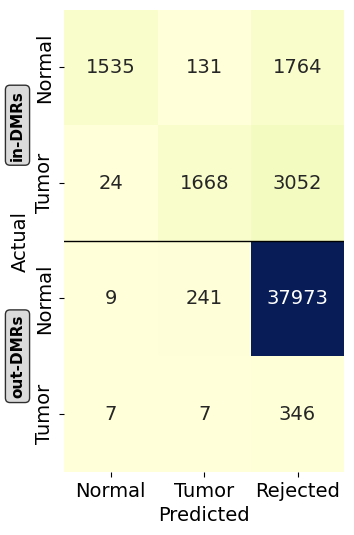

In [509]:
# Create a confusion matrix
cm = confusion_matrix(
    predictions_whole["label_combined"], predictions_whole["prediction"]
)
cm = np.concatenate([cm[:2, :3], cm[3:, :3]], axis=0)
mcc = matthews_corrcoef(covered_subset["label"], covered_subset["prediction"])
# Computing F1:
pr_n = (cm[0][0] + cm[2][0]) / np.sum(cm[:, 0])
r_n = cm[0][0] / np.sum(cm[0, :2])
f1_normal = 2 * pr_n * r_n / (pr_n + r_n)

pr_t = (cm[1][1] + cm[3][1]) / np.sum(cm[:, 1])
r_t = cm[1][1] / np.sum(cm[1, :2])
f1_tumour = 2 * pr_t * r_t / (pr_t + r_t)

coverage = np.sum(cm[:2, :2]) / np.sum(cm[:2, :3])

fig, ax = plt.subplots(figsize=(4, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    yticklabels=["Normal", "Tumor", "Normal", "Tumor"],
    xticklabels=["Normal", "Tumor", "Rejected"],
    ax=ax,
    cbar=False,
    annot_kws={"fontsize": 14},
)

# Add horizontal line to separate groups
ax.axhline(y=2, color="black", linewidth=1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# Add group labels with background
bbox_props = dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8)
ax.text(
    -0.5,
    1,
    "in-DMRs",
    rotation=90,
    va="center",
    ha="center",
    fontsize=11,
    weight="bold",
    bbox=bbox_props,
)
ax.text(
    -0.5,
    3,
    "out-DMRs",
    rotation=90,
    va="center",
    ha="center",
    fontsize=11,
    weight="bold",
    bbox=bbox_props,
)

plt.xlabel("Predicted", fontsize=14)
plt.ylabel("Actual", fontsize=14)
plt.subplots_adjust(left=0.2)  # Make room for group labels
# plt.title(f'Mixed Model. Coverage: {coverage:.1%} \n F1 Normal (In Coverage): {f1_normal:.1%}. \n F1 Tumour (In Coverage): {f1_tumour:.1%} \n MCC (In Coverage) {mcc:.1%}',fontsize=16)
print(
    f"Mixed Model. Coverage: {coverage:.1%} \n F1 Normal (In Coverage): {f1_normal:.1%}. \n F1 Tumour (In Coverage): {f1_tumour:.1%} \n MCC (In Coverage) {mcc:.1%})"
)

plt.show()

In [ ]:
import pickle

with open("chr16_test_selected_reads_mixed_model_predictions.pkl", "wb") as f:
    pickle.dump((predictions_whole, predictions), f)

### Whole reads informative model

In [63]:
target_run["artifact_uri"].to_numpy()[0]

'mlflow-artifacts:/564481821195479800/ecf48474e9d145ffa31b3538437e39e9/artifacts'

In [64]:
tmp_path = mlflow.artifacts.download_artifacts(
    target_run["artifact_uri"].to_numpy()[0]
    + "/predictions/test_whole_reads_predictions.pkl"
)
f = open(tmp_path, "rb")
predictions_informative_model = pickle.load(f)
f.close()

In [271]:
predictions_informative_model = predictions_whole[
    predictions_whole["label_combined"] < 2
][
    [
        "read_name",
        "read_start",
        "read_end",
        "chromosome",
        "original_file",
        "overlap_names",
    ]
].merge(
    predictions_whole_infromative, on="read_name"
)

In [272]:
predictions_informative_model["predicted_probability"] = predictions_informative_model[
    "prediction"
]
predictions_informative_model["true_label"] = predictions_informative_model["label"]
predictions_informative_model["predicted_label"] = (
    predictions_informative_model["prediction"] >= 0.5
)

In [291]:
predictions_informative_model["predicted_label_wr"] = np.where(
    predictions_informative_model["prediction"] >= 0.89,
    1,
    np.where(predictions_informative_model["prediction"] <= 0.11, 0, 2),
)

In [295]:
count_unique_positions(subset)

np.int64(977112)

In [293]:
subset.shape

(3481, 12)

In [282]:
from sklearn.metrics import f1_score

Informative Model. 
 F1 Normal: 94.3%. F1 Tumour: 96.8% 
 MCC 91.4% 


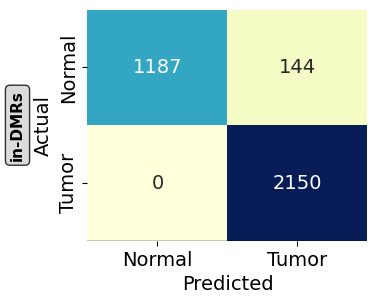

In [292]:
# Create a confusion matrix
subset = predictions_informative_model[
    predictions_informative_model["predicted_label_wr"] != 2
]
cm = confusion_matrix(subset["true_label"], subset["predicted_label"])
f1_normal, f1_tumour = f1_score(
    subset["true_label"], subset["predicted_label"], average=None
)
mcc = matthews_corrcoef(subset["true_label"], subset["predicted_label"])
# Plot the confusion matrix

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    yticklabels=["Normal", "Tumor"],
    xticklabels=["Normal", "Tumor"],
    ax=ax,
    cbar=False,
    annot_kws={"fontsize": 14},
)

# Add horizontal line to separate groups
ax.axhline(y=2, color="black", linewidth=1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# Add group labels with background
bbox_props = dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8)
ax.text(
    -0.5,
    1,
    "in-DMRs",
    rotation=90,
    va="center",
    ha="center",
    fontsize=11,
    weight="bold",
    bbox=bbox_props,
)

plt.xlabel("Predicted", fontsize=14)
plt.ylabel("Actual", fontsize=14)
plt.subplots_adjust(left=0.2)  # Make room for group labels
# plt.title(f'Informative Model. \n F1 Normal: {f1_normal:.1%}. F1 Tumour: {f1_tumour:.1%} \n MCC {mcc:.1%} ',fontsize=16)
print(
    f"Informative Model. \n F1 Normal: {f1_normal:.1%}. F1 Tumour: {f1_tumour:.1%} \n MCC {mcc:.1%} "
)
plt.show()

### Whole reads - entire chromosome

In [47]:
max_read_length = test_data["sequence_length"].max()

In [48]:
from math import ceil

In [499]:
import pickle

with open("chr19_test_all_reads_mixed_model_v2_predictions.pkl", "rb") as f:
    predictions_whole = pickle.load(f)

In [337]:
len(test_data)

951934

In [ ]:
import torch
import gc

In [ ]:
predictions_whole = pd.DataFrame(
    {
        "read_name": read_names,
        "prediction": np.argmax(np.exp(predictions), axis=1),
        "label": labels,
    }
)

In [ ]:
# import pickle
# with open("chr19_test_all_reads_mixed_model_predictions.pkl", "wb") as f:
#     pickle.dump((predictions_whole, predictions), f)

In [ ]:
from scipy.special import softmax

In [500]:
predictions_whole = predictions_whole.merge(
    test_data[
        [
            "read_name",
            "read_start",
            "read_end",
            "chromosome",
            "original_file",
            "overlap_names",
            "sequence_length",
        ]
    ],
    on="read_name",
)

In [62]:
from scipy.special import softmax

In [64]:
predictions_df = pd.DataFrame(
    softmax(np.exp(predictions), axis=1), columns=["normal", "tumor", "reject"]
)

In [65]:
predictions_df["highest_score"] = predictions_df.max(axis=1)

In [66]:
predictions_df["reject_dif"] = (
    predictions_df["reject"] - predictions_df["highest_score"]
)

In [76]:
predictions_whole["prediction_corrected"] = [
    x["prediction"] if x["reject_dif"] > -0.1 else 2
    for _, x in predictions_whole.iterrows()
]

In [82]:
predictions_whole.loc[0]["reject_dif"]

np.float64(-0.8258698538903133)

In [235]:
predictions_whole["chromosome"] = "chr19"

In [239]:
covered_subset.shape

(21436, 12)

In [55]:
predictions_whole["predicted_label_wr"] = np.where(
    predictions_whole["proba_rejection"] >= 0.5, 2, predictions_whole["prediction"]
)

Mixed Model. Coverage: 2.7% 
 F1 Normal (In Coverage): 52.4%. 
 F1 Tumour (In Coverage): 73.9% 
 MCC (In Coverage) 41.8%


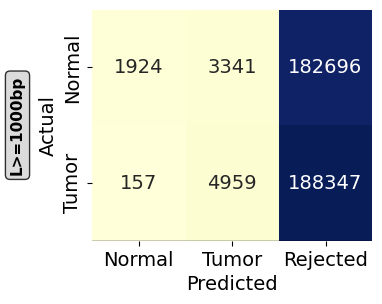

In [501]:
# Create a confusion matrix
min_sequence_length = 1000
subset = predictions_whole[predictions_whole["sequence_length"] >= min_sequence_length]


cm = confusion_matrix(subset["label"], subset["prediction"])
cm = cm[:2, :]
f1_normal, f1_tumour = f1_score(
    subset["label"][subset["prediction"] != 2],
    subset["prediction"][subset["prediction"] != 2],
    average=None,
)
coverage = np.sum(cm[:, :2]) / np.sum(cm)
covered_subset = subset[subset["prediction"] != 2]
mcc = matthews_corrcoef(covered_subset["label"], covered_subset["prediction"])
# Plot the confusion matrix

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    yticklabels=["Normal", "Tumor"],
    xticklabels=["Normal", "Tumor", "Rejected"],
    ax=ax,
    cbar=False,
    annot_kws={"fontsize": 14},
)

# Add horizontal line to separate groups
ax.axhline(y=2, color="black", linewidth=1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# Add group labels with background
bbox_props = dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8)
ax.text(
    -0.8,
    1,
    "L>=1000bp",
    rotation=90,
    va="center",
    ha="center",
    fontsize=11,
    weight="bold",
    bbox=bbox_props,
)

plt.xlabel("Predicted", fontsize=14)
plt.ylabel("Actual", fontsize=14)
plt.subplots_adjust(left=0.2)  # Make room for group labels
# plt.title(f'Mixed Model. Coverage: {coverage:.1%} \n F1 Normal (In Coverage): {f1_normal:.1%}. \n F1 Tumour (In Coverage): {f1_tumour:.1%} \n MCC (In Coverage) {mcc:.1%}',fontsize=16)
print(
    f"Mixed Model. Coverage: {coverage:.1%} \n F1 Normal (In Coverage): {f1_normal:.1%}. \n F1 Tumour (In Coverage): {f1_tumour:.1%} \n MCC (In Coverage) {mcc:.1%}"
)
plt.show()


# sns.heatmap(cm, annot=True,fmt='d', cmap='YlGnBu', yticklabels=["Normal", "Tumour"], xticklabels=["Normal", "Tumour", "Rejected"])
# plt.xlabel('Predicted', fontsize=12)
# plt.ylabel('Actual', fontsize=12)

# plt.show()

In [240]:
import pickle

with open("chr19_fifth_pair_informative_model_predictions.pkl", "rb") as f:
    predictions_whole_canonical = pickle.load(f)

In [241]:
predictions_whole_canonical = predictions_whole_canonical.merge(
    test_data[["read_name", "sequence_length", "read_start", "read_end"]],
    on=["read_name"],
)

In [245]:
predictions_whole_canonical["chromosome"] = "chr19"

In [260]:
predictions_whole_canonical["predicted_label_wr"] = np.where(
    predictions_whole_canonical["prediction"] >= 0.895,
    1,
    np.where(predictions_whole_canonical["prediction"] <= 0.105, 0, 2),
)

In [ ]:
# predictions_whole_canonical["predicted_label_wr"]=1

Mixed Model. Coverage: 100.0% 
 F1 Normal (In Coverage): 24.1%. 
 F1 Tumour (In Coverage): 76.9% 
 MCC 28.8%


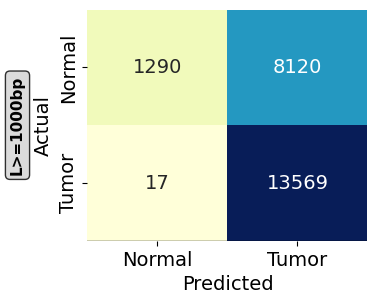

In [261]:
# Create a confusion matrix
min_sequence_length = 0
subset = predictions_whole_canonical[
    (predictions_whole_canonical["sequence_length"] >= min_sequence_length)
    & (predictions_whole_canonical["predicted_label_wr"] != 2)
]
cm = confusion_matrix(subset["label"], subset["prediction"] > 0.5)
mcc = matthews_corrcoef(subset["label"], subset["prediction"] > 0.5)

f1_normal, f1_tumour = f1_score(
    subset["label"], subset["prediction"] > 0.5, average=None
)
coverage = 1

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    yticklabels=["Normal", "Tumor"],
    xticklabels=["Normal", "Tumor"],
    ax=ax,
    cbar=False,
    annot_kws={"fontsize": 14},
)

# Add horizontal line to separate groups
ax.axhline(y=2, color="black", linewidth=1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# Add group labels with background
bbox_props = dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8)
ax.text(
    -0.5,
    1,
    "L>=1000bp",
    rotation=90,
    va="center",
    ha="center",
    fontsize=11,
    weight="bold",
    bbox=bbox_props,
)

plt.xlabel("Predicted", fontsize=14)
plt.ylabel("Actual", fontsize=14)
plt.subplots_adjust(left=0.2)  # Make room for group labels
# plt.title(f'Mixed Model. Coverage: {coverage:.1%} \n F1 Normal (In Coverage): {f1_normal:.1%}. \n F1 Tumour (In Coverage): {f1_tumour:.1%} \n MCC {mcc:.1%}',fontsize=16)
print(
    f"Mixed Model. Coverage: {coverage:.1%} \n F1 Normal (In Coverage): {f1_normal:.1%}. \n F1 Tumour (In Coverage): {f1_tumour:.1%} \n MCC {mcc:.1%}"
)
plt.show()

In [262]:
count_unique_positions(subset) / (90 * 10**6) * 100, subset.shape[0] / 951934 * 100

(np.float64(17.220497777777776), 2.4157136944367994)

### Building MCC-rejection curves

In [464]:
chromosome = "chr19"
min_sequence_length = 0

if chromosome == "chr16":
    mixed_predictions_path = "chr16_test_all_reads_mixed_model_predictions_v3.pkl"
    informative_predictions_path = "chr16_fifth_pair_informative_model_predictions.pkl"
elif chromosome == "chr19":
    mixed_predictions_path = "chr19_test_all_reads_mixed_model_v2_predictions.pkl"
    informative_predictions_path = "chr19_fifth_pair_informative_model_predictions.pkl"

In [465]:
import pickle

with open(mixed_predictions_path, "rb") as f:
    predictions_whole_mixed_model = pickle.load(f)

In [466]:
import pickle

with open(informative_predictions_path, "rb") as f:
    predictions_whole_infromative = pickle.load(f)

In [467]:
data_list = [
    load_and_filter_data(path, chromosome)
    for path in [normal_parquet_files[4], tumour_parquet_files[4]]
]
test_data = pd.concat(data_list)
del data_list

In [468]:
predictions_whole_mixed_model = predictions_whole_mixed_model.merge(
    test_data[
        [
            "read_name",
            "read_start",
            "read_end",
            "chromosome",
            "original_file",
            "overlap_names",
            "sequence_length",
        ]
    ],
    on="read_name",
)
predictions_whole_infromative = predictions_whole_infromative.merge(
    test_data[
        [
            "read_name",
            "read_start",
            "read_end",
            "chromosome",
            "original_file",
            "overlap_names",
            "sequence_length",
        ]
    ],
    on="read_name",
)

In [469]:
predictions_whole_mixed_model["chromosome"] = chromosome
predictions_whole_infromative["chromosome"] = chromosome

In [470]:
from copy import deepcopy

In [471]:
results_informative = []
supersub = deepcopy(
    predictions_whole_infromative[
        (predictions_whole_infromative["sequence_length"] >= min_sequence_length)
    ]
)
for i in tqdm(range(1, 500, 1)):
    tr = 0.5 + i / 1000
    supersub["predicted_label_wr"] = np.where(
        supersub["prediction"] >= tr,
        1,
        np.where(supersub["prediction"] <= 1 - tr, 0, 2),
    )

    subset = supersub[(supersub["predicted_label_wr"] != 2)]
    mcc = matthews_corrcoef(subset["label"], subset["prediction"] > 0.5)
    unique_nucleotides = count_unique_positions(subset)
    n_reads = len(subset)
    results_informative.append((mcc, n_reads, unique_nucleotides))

100%|██████████| 499/499 [02:34<00:00,  3.23it/s] 


In [472]:
results_mixed = []
supersub = deepcopy(
    predictions_whole_mixed_model[
        (predictions_whole_mixed_model["sequence_length"] >= min_sequence_length)
    ]
)
for i in tqdm(range(0, 660, 1)):
    tr = 0.34 + i / 1000
    supersub["predicted_label_wr"] = np.where(
        supersub["proba_tumor"] >= tr, 1, np.where(supersub["proba_normal"] >= tr, 0, 2)
    )
    subset = supersub[
        (supersub["sequence_length"] >= min_sequence_length)
        & (supersub["predicted_label_wr"] != 2)
        & (supersub["prediction"] != 2)
    ]
    mcc = matthews_corrcoef(
        subset["label"], np.argmax(subset[["proba_normal", "proba_tumor"]], axis=1)
    )
    unique_nucleotides = count_unique_positions(subset)
    n_reads = len(subset)
    results_mixed.append((mcc, n_reads, unique_nucleotides))

100%|██████████| 660/660 [00:27<00:00, 23.77it/s]


In [473]:
if chromosome == "chr19":
    chr_len = 59 * 10**6
elif chromosome == "chr16":
    chr_len = 90 * 10**6

n = len(predictions_whole_infromative)
results_informative = [(x, y / n, z / chr_len) for (x, y, z) in results_informative]
results_mixed = [(x, y / n, z / chr_len) for (x, y, z) in results_mixed]

In [474]:
results_informative = list(set(results_informative))
results_mixed = list(set(results_mixed))

In [475]:
import matplotlib.pyplot as plt
import numpy as np


def plot_classifier_performance(
    systems_data, system_names, coverage_type="reads", figsize=(10, 6)
):
    """
    Plot classifier performance with rejection showing MCC vs coverage.

    Parameters:
    -----------
    systems_data : list of lists of tuples
        Each inner list represents a system, containing tuples of (MCC, coverage_reads, coverage_length)
        All values are decimals from 0 to 1
    system_names : list of str
        Names for each system (must match length of systems_data)
    coverage_type : str
        Either 'reads' or 'length' to select which coverage to plot
    figsize : tuple
        Figure size (width, height)

    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """

    if len(systems_data) != len(system_names):
        raise ValueError("Number of systems must match number of system names")

    if coverage_type not in ["reads", "length"]:
        raise ValueError("coverage_type must be either 'reads' or 'length'")

    # Create figure and axis
    fig, ax = plt.subplots(figsize=figsize)

    # Define colors for different systems
    colors = plt.cm.tab10(np.linspace(0, 1, len(systems_data)))

    # Determine which coverage index to use
    coverage_idx = 1 if coverage_type == "reads" else 2
    coverage_label = (
        "Coverage in reads" if coverage_type == "reads" else "Coverage in length"
    )

    # Plot each system
    for i, (system_data, name) in enumerate(zip(systems_data, system_names)):
        # Extract data
        mcc_values = [t[0] for t in system_data]
        coverage_values = [t[coverage_idx] for t in system_data]

        # Sort by coverage for proper line plotting
        sorted_indices = np.argsort(coverage_values)
        coverage_sorted = [coverage_values[j] for j in sorted_indices]
        mcc_sorted = [mcc_values[j] for j in sorted_indices]

        # Plot line
        ax.plot(
            coverage_sorted,
            mcc_sorted,
            "o-",
            color=colors[i],
            label=name,
            markersize=4,
            linewidth=2,
        )

    # Set labels and formatting
    ax.set_xlabel(coverage_label, fontsize=16)
    ax.set_ylabel("MCC", fontsize=16)
    # ax.set_title(f'Classifier Performance with Rejection ({coverage_label})', fontsize=14)
    ax.grid(True, alpha=0.3, which="both")
    ax.legend(loc="best", fontsize=16)

    # Set to semilog scale
    ax.set_xscale("log")

    # Set axis limits
    ax.set_xlim(0.001, 1.05)  # Start from 0.001 for log scale
    ax.set_ylim(auto=True)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    # Format x-axis as percentage with conditional formatting
    def format_percentage(x, p):
        if x >= 0.01:
            return f"{x*100:.0f}%"
        else:
            return f"{x*100:.1f}%"

    ax.xaxis.set_major_formatter(plt.FuncFormatter(format_percentage))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x*100:.0f}%"))

    # Add minor gridlines for log scale
    ax.grid(True, which="minor", alpha=0.1)

    return fig, ax


# Convenience function to plot from a dictionary
def plot_multiple_classifiers(data_dict, coverage_type="reads", figsize=(10, 6)):
    """
    Convenience function to plot from a dictionary.

    Parameters:
    -----------
    data_dict : dict
        Dictionary with system names as keys and list of tuples as values
    coverage_type : str
        Either 'reads' or 'length' to select which coverage to plot
    figsize : tuple
        Figure size

    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    system_names = list(data_dict.keys())
    systems_data = list(data_dict.values())

    return plot_classifier_performance(
        systems_data, system_names, coverage_type, figsize
    )


# Function to create comparison plots (both coverage types side by side)
def plot_comparison(systems_data, system_names, figsize=(16, 6)):
    """
    Create side-by-side plots for both coverage types.

    Parameters:
    -----------
    systems_data : list of lists of tuples
        Each inner list represents a system, containing tuples of (MCC, coverage_reads, coverage_length)
    system_names : list of str
        Names for each system
    figsize : tuple
        Figure size for the combined plot

    Returns:
    --------
    fig : matplotlib figure object
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # Define colors for consistent coloring across subplots
    colors = plt.cm.tab10(np.linspace(0, 1, len(systems_data)))

    # Plot coverage in reads
    for i, (system_data, name) in enumerate(zip(systems_data, system_names)):
        mcc_values = [t[0] for t in system_data]
        coverage_reads = [t[1] for t in system_data]

        sorted_indices = np.argsort(coverage_reads)
        coverage_sorted = [coverage_reads[j] for j in sorted_indices]
        mcc_sorted = [mcc_values[j] for j in sorted_indices]

        ax1.plot(
            coverage_sorted,
            mcc_sorted,
            "o-",
            color=colors[i],
            label=name,
            markersize=6,
            linewidth=2,
        )

    ax1.set_xlabel("Coverage in reads", fontsize=12)
    ax1.set_ylabel("MCC", fontsize=12)
    ax1.set_title("Performance vs Coverage in reads", fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc="best")
    ax1.set_xlim(-0.05, 1.05)
    ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x*100:.0f}%"))

    # Plot coverage in length
    for i, (system_data, name) in enumerate(zip(systems_data, system_names)):
        mcc_values = [t[0] for t in system_data]
        coverage_length = [t[2] for t in system_data]

        sorted_indices = np.argsort(coverage_length)
        coverage_sorted = [coverage_length[j] for j in sorted_indices]
        mcc_sorted = [mcc_values[j] for j in sorted_indices]

        ax2.plot(
            coverage_sorted,
            mcc_sorted,
            "o-",
            color=colors[i],
            label=name,
            markersize=6,
            linewidth=2,
        )

    ax2.set_xlabel("Coverage in length", fontsize=12)
    ax2.set_ylabel("MCC", fontsize=12)
    ax2.set_title("Performance vs Coverage in length", fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc="best")
    ax2.set_xlim(-0.05, 1.05)
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x*100:.0f}%"))

    plt.tight_layout()
    return fig

In [515]:
ri = pd.DataFrame(results_mixed, columns=["mcc", "covreads", "covlength"])

In [518]:
ri[ri["mcc"] > 0.8]

,mcc,covreads,covlength
138,0.822931,0.004351,0.014714
148,0.807154,0.004457,0.016389
464,0.847193,0.004196,0.012518


(<Figure size 500x400 with 1 Axes>,
 <Axes: xlabel='Coverage in reads', ylabel='MCC'>)

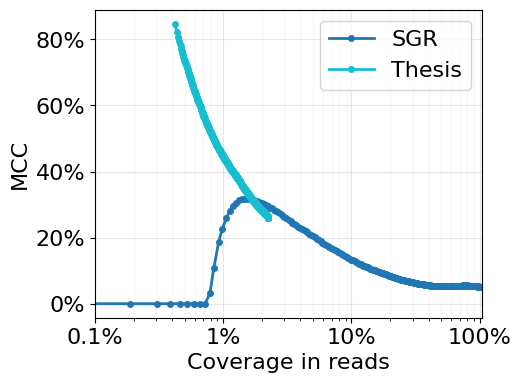

In [478]:
plot_multiple_classifiers(
    {"SGR": results_informative, "Thesis": results_mixed},
    coverage_type="reads",
    figsize=(5, 4),
)

'../Data/Curated/experiment_c/chr16_all_lengths'